# CIFAR-10 Transfer Learning with Keras 3

This complete workflow freezes an ImageNet-pretrained VGG16 feature extractor and trains a
CIFAR-10 classifier. The split, head intent, ten-epoch maximum, and evaluation
are aligned across frameworks.

A network connection is required the first time the pretrained weights are
cached. To run the example more quickly, set `EPOCHS` to 1 or 2 in the data cell.

## Runtime dependency check

In [1]:
import importlib.util
import subprocess
import sys
from pathlib import Path

REQUIRED_RUNTIME = {'keras': 'keras', 'torch': 'torch'}
COLAB_EXTRAS = {}
missing_required = [
    package for module, package in REQUIRED_RUNTIME.items()
    if importlib.util.find_spec(module) is None
]
missing_extras = [
    package for module, package in COLAB_EXTRAS.items()
    if importlib.util.find_spec(module) is None
]
if missing_extras and "google.colab" in sys.modules:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_extras]
    )
    missing_extras = []
if missing_required or missing_extras:
    missing = ", ".join(missing_required + missing_extras)
    raise RuntimeError(
        f"Missing notebook dependencies: {missing}. Locally run "
        "`uv sync --group notebooks`; in Colab restart the runtime if an "
        "installation cell just changed the environment."
    )
print("runtime dependency check passed")

runtime dependency check passed


In [2]:
%matplotlib inline

## Keras-to-PyTorch crosswalk

This optional implementation uses the same Torch runtime as the canonical
native PyTorch path. Keras `compile()` selects the optimizer and loss,
`fit()` owns the explicit batch and epoch loop, and callbacks provide
high-level training control. Data, splits, budgets, evidence, and scientific
conclusions remain aligned with the canonical PyTorch workflow.

## Imports and shared CIFAR-10 split

In [3]:
import hashlib
import json
import os

os.environ["KERAS_BACKEND"] = "torch"

import keras
import matplotlib.pyplot as plt
import numpy as np
import torch
from keras import layers
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split

assert keras.backend.backend() == "torch"
print(
    f"Keras {keras.__version__}; backend={keras.backend.backend()}; "
    f"PyTorch {torch.__version__}"
)

Keras 3.15.1; backend=torch; PyTorch 2.13.0


In [4]:
SEED = 42
EPOCHS = 10  # Reduce to 1 or 2 for a quicker run.
BATCH_SIZE = 256

keras.utils.set_random_seed(SEED)
torch.use_deterministic_algorithms(True)

(x_development, y_development), (x_test, y_test) = keras.datasets.cifar10.load_data()
y_development = y_development.reshape(-1)
y_test = y_test.reshape(-1)
all_indices = np.arange(len(y_development))
train_indices, validation_indices = train_test_split(
    all_indices,
    test_size=5000,
    random_state=SEED,
    stratify=y_development,
)
split_signature = hashlib.sha256(
    validation_indices.astype("<i8").tobytes()
).hexdigest()[:16]

x_train = x_development[train_indices].astype("float32") / 255.0
y_train = y_development[train_indices].astype(np.int64)
x_validation = x_development[validation_indices].astype("float32") / 255.0
y_validation = y_development[validation_indices].astype(np.int64)
x_test = x_test.astype("float32") / 255.0
y_test = y_test.astype(np.int64)


assert set(train_indices).isdisjoint(validation_indices)
print(f"split signature: {split_signature}")
print(
    f"train={len(y_train):,}, validation={len(y_validation):,}, "
    f"test={len(y_test):,}, epochs={EPOCHS}"
)

split signature: bfa7941b2b58be94
train=45,000, validation=5,000, test=10,000, epochs=10


## Inspect class coverage

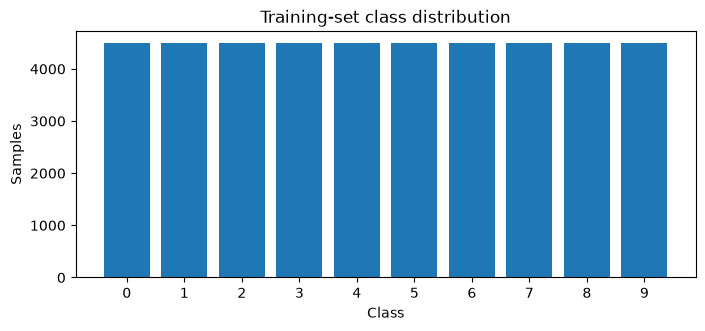

In [5]:
training_counts = np.bincount(y_train, minlength=10)
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(np.arange(10), training_counts)
ax.set(
    title="Training-set class distribution",
    xlabel="Class",
    ylabel="Samples",
    xticks=np.arange(10),
)
plt.show()

## Preprocess for VGG16 and define the trainable head

In [6]:
x_train = keras.applications.vgg16.preprocess_input(x_train * 255.0)
x_validation = keras.applications.vgg16.preprocess_input(x_validation * 255.0)
x_test_images = x_test.copy()
x_test = keras.applications.vgg16.preprocess_input(x_test * 255.0)
base_model = keras.applications.VGG16(
    include_top=False, weights="imagenet", input_shape=(32, 32, 3)
)
base_model.trainable = False
print("extracting frozen VGG16 features once per split")
x_train = base_model.predict(
    x_train, batch_size=BATCH_SIZE, verbose=1
).reshape(len(x_train), -1)
x_validation = base_model.predict(
    x_validation, batch_size=BATCH_SIZE, verbose=1
).reshape(len(x_validation), -1)
x_test = base_model.predict(
    x_test, batch_size=BATCH_SIZE, verbose=1
).reshape(len(x_test), -1)
model = keras.Sequential(
    [
        keras.Input(shape=(x_train.shape[1],)),
        layers.Dense(512, activation='relu'), layers.Dropout(0.25), layers.Dense(256, activation='relu'), layers.Dropout(0.25),
        layers.Dense(10),
    ],
    name="vgg16_frozen_features",
)
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)
print(f"trainable parameters: {sum(np.prod(v.shape) for v in model.trainable_weights):,}")
model.summary()

extracting frozen VGG16 features once per split


  1/176 ━━━━━━━━━━━━━━━━━━━━ 52s 298ms/step

  3/176 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step  

  5/176 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step

  7/176 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step

...

Model: "vgg16_frozen_features"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 396,554 (1.51 MB)

 Trainable params: 396,554 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

## Train with validation-based early stopping

Epoch 1/10


176/176 - 1s - 7ms/step - accuracy: 0.4539 - loss: 2.1779 - val_accuracy: 0.5932 - val_loss: 1.1905


Epoch 2/10


176/176 - 1s - 7ms/step - accuracy: 0.5726 - loss: 1.2374 - val_accuracy: 0.6316 - val_loss: 1.0662


Epoch 3/10


...

176/176 - 1s - 6ms/step - accuracy: 0.7222 - loss: 0.7740 - val_accuracy: 0.6856 - val_loss: 0.9285


Epoch 9/10


176/176 - 1s - 6ms/step - accuracy: 0.7365 - loss: 0.7370 - val_accuracy: 0.6800 - val_loss: 0.9406


Epoch 10/10


176/176 - 1s - 6ms/step - accuracy: 0.7518 - loss: 0.6928 - val_accuracy: 0.6796 - val_loss: 0.9555


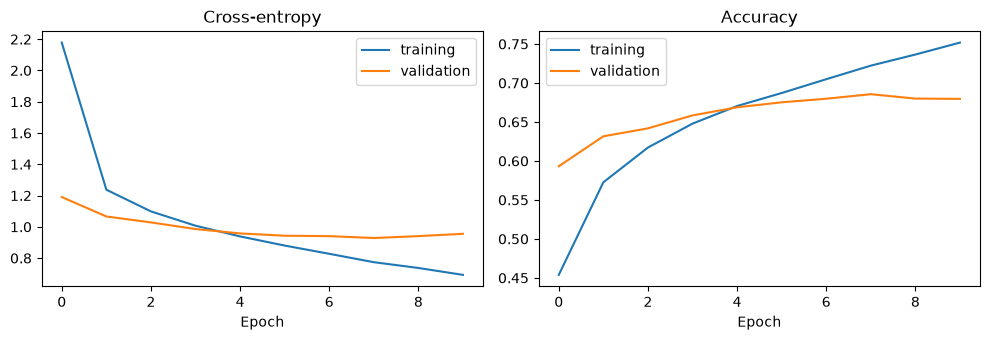

In [7]:
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_validation, y_validation),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=2, restore_best_weights=True
        )
    ],
    verbose=2,
)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(history.history["loss"], label="training")
axes[0].plot(history.history["val_loss"], label="validation")
axes[0].set(title="Cross-entropy", xlabel="Epoch")
axes[1].plot(history.history["accuracy"], label="training")
axes[1].plot(history.history["val_accuracy"], label="validation")
axes[1].set(title="Accuracy", xlabel="Epoch")
for axis in axes:
    axis.legend()
plt.tight_layout()
plt.show()

## Final test evidence

test accuracy: 0.6738
              precision    recall  f1-score   support

           0      0.743     0.733     0.738      1000
           1      0.758     0.751     0.754      1000
           2      0.635     0.504     0.562      1000
           3      0.505     0.512     0.509      1000
           4      0.595     0.630     0.612      1000
           5      0.639     0.601     0.619      1000
           6      0.655     0.798     0.720      1000
           7      0.739     0.689     0.713      1000
           8      0.778     0.762     0.770      1000
           9      0.697     0.758     0.726      1000

    accuracy                          0.674     10000
   macro avg      0.674     0.674     0.672     10000
weighted avg      0.674     0.674     0.672     10000

HELIO_RESULT {"confusion_shape": [10, 10], "split_signature": "bfa7941b2b58be94", "test_accuracy": 0.6738}


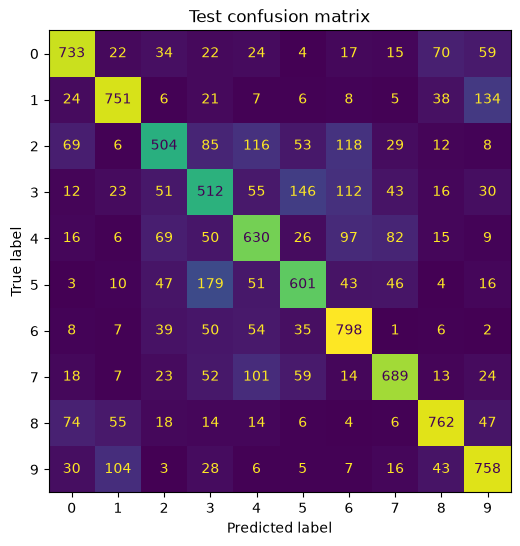

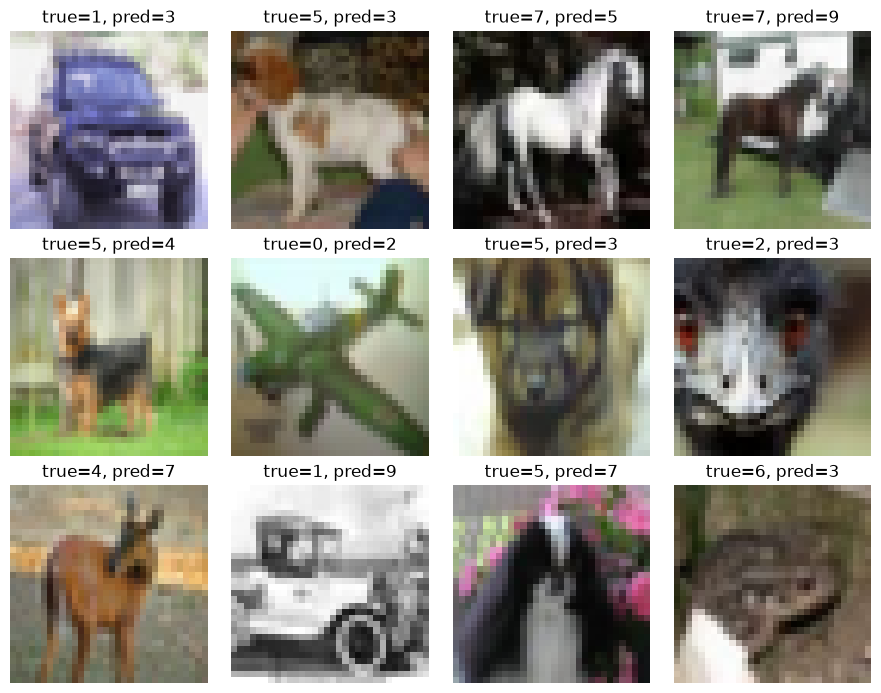

In [8]:
test_logits = model.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
test_predictions = test_logits.argmax(axis=1)

test_accuracy = accuracy_score(y_test, test_predictions)
cm = confusion_matrix(y_test, test_predictions, labels=np.arange(10))
print(f"test accuracy: {test_accuracy:.4f}")
print(
    classification_report(
        y_test,
        test_predictions,
        labels=np.arange(10),
        digits=3,
        zero_division=0,
    )
)
print(
    "HELIO_RESULT "
    + json.dumps(
        {
            "split_signature": split_signature,
            "test_accuracy": float(test_accuracy),
            "confusion_shape": list(cm.shape),
        },
        sort_keys=True,
    )
)
assert cm.shape == (10, 10)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=np.arange(10)).plot(
    ax=ax, colorbar=False, values_format="d"
)
ax.set_title("Test confusion matrix")
plt.show()

mistakes = np.flatnonzero(test_predictions != y_test)[:12]
if len(mistakes):
    fig, axes = plt.subplots(3, 4, figsize=(9, 7))
    for axis, index in zip(axes.flat, mistakes):
        image = x_test_images[index]
        if image.shape[0] in (1, 3):
            image = np.transpose(image, (1, 2, 0))
        axis.imshow(image.squeeze(), cmap="gray" if image.squeeze().ndim == 2 else None)
        axis.set_title(f"true={y_test[index]}, pred={test_predictions[index]}")
        axis.axis("off")
    plt.tight_layout()
    plt.show()

## Try it yourself in Keras

Change one choice at a time and keep the data split and evaluation unchanged:

- replace the 512→256 classifier with one 256-unit layer.
- change the classifier dropout while keeping VGG16 frozen.
- unfreeze only the final VGG16 block and use a smaller learning rate.